In [1]:
from data import load_mri_dataframe, get_dataloaders

In [2]:
df = load_mri_dataframe()

train_loader, val_loader = get_dataloaders(df, omit_empty_masks=True)

[Data] Train images: 1093 ; Val images: 280


In [3]:
import torch
import torch.nn as nn

In [4]:
class BaselineUNet(nn.Module):
    def __init__(self):
        super().__init__()
        num_classes = 1
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)  # 128x128

        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)  # 64x64

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())

        # Decoder
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)  # 64x64
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)  # 128x128
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())

        # Final
        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.final(d1)


In [5]:
model = BaselineUNet()

device = torch.device('cuda')

Epoch 1/10: 100%|██████████| 137/137 [00:03<00:00, 39.38it/s, train_loss=0.1826]


Epoch 1/10 - Avg Train Loss: 0.1826


Epoch 2/10: 100%|██████████| 137/137 [00:03<00:00, 39.46it/s, train_loss=0.0642]


Epoch 2/10 - Avg Train Loss: 0.0642


Epoch 3/10: 100%|██████████| 137/137 [00:03<00:00, 42.62it/s, train_loss=0.0604]


...

Epoch 8/10 - Avg Train Loss: 0.0539


Epoch 9/10: 100%|██████████| 137/137 [00:03<00:00, 41.38it/s, train_loss=0.0533]


Epoch 9/10 - Avg Train Loss: 0.0533


Epoch 10/10: 100%|██████████| 137/137 [00:03<00:00, 41.52it/s, train_loss=0.0527]


Epoch 10/10 - Avg Train Loss: 0.0527
Final Val Dice: 0.5241
Final Val IoU : 0.4274


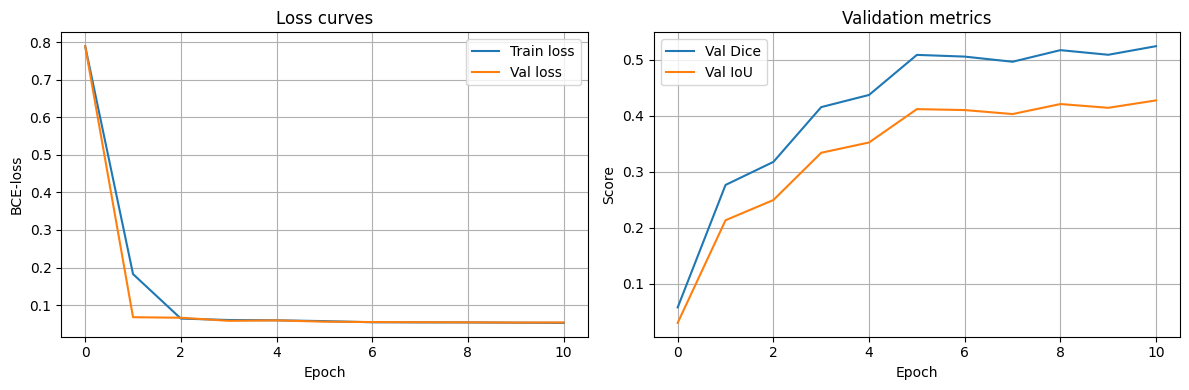

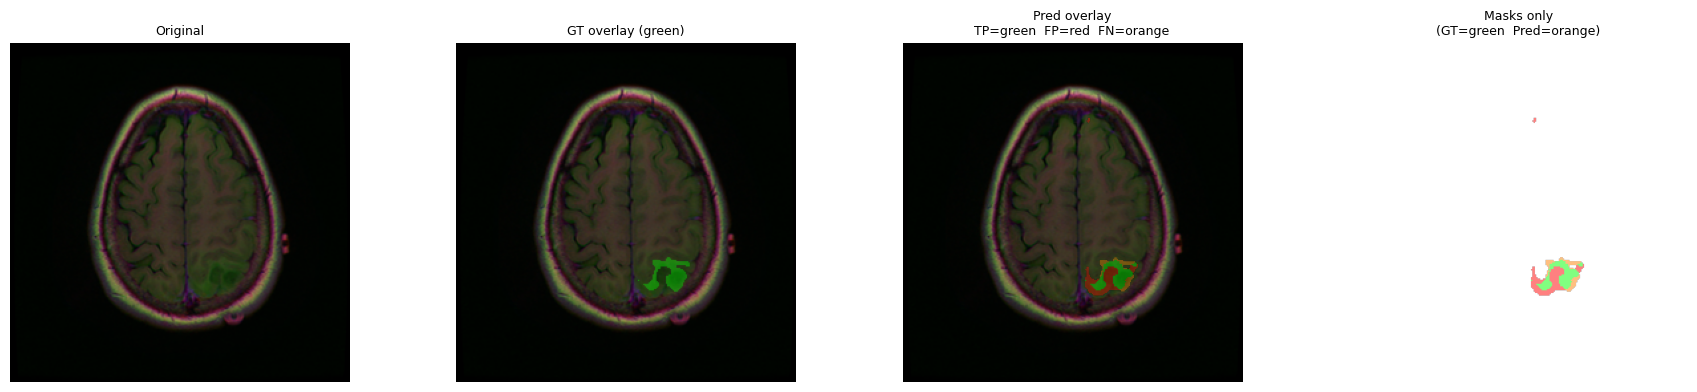

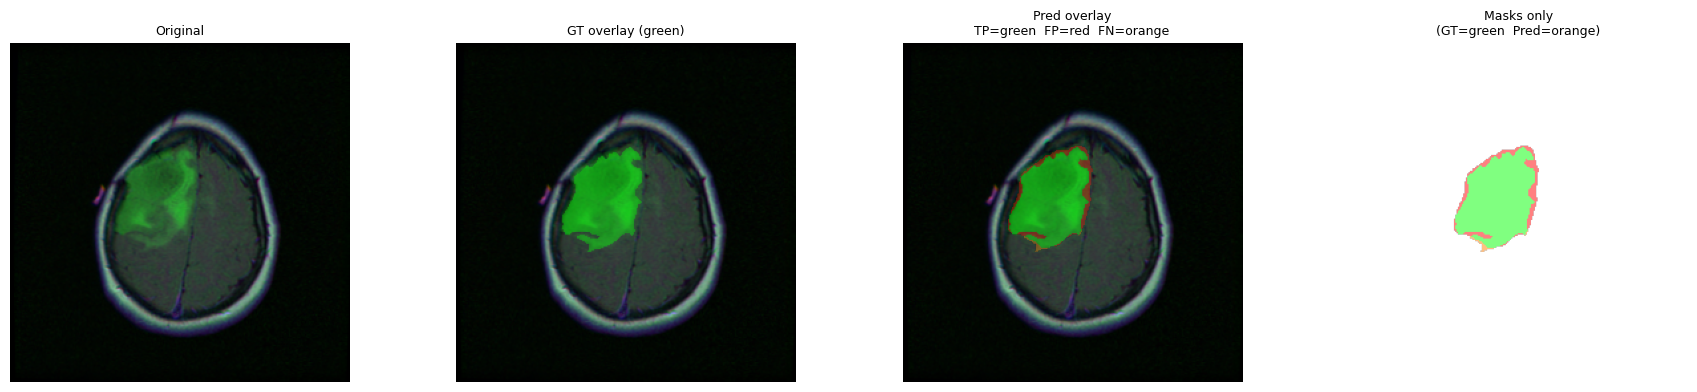

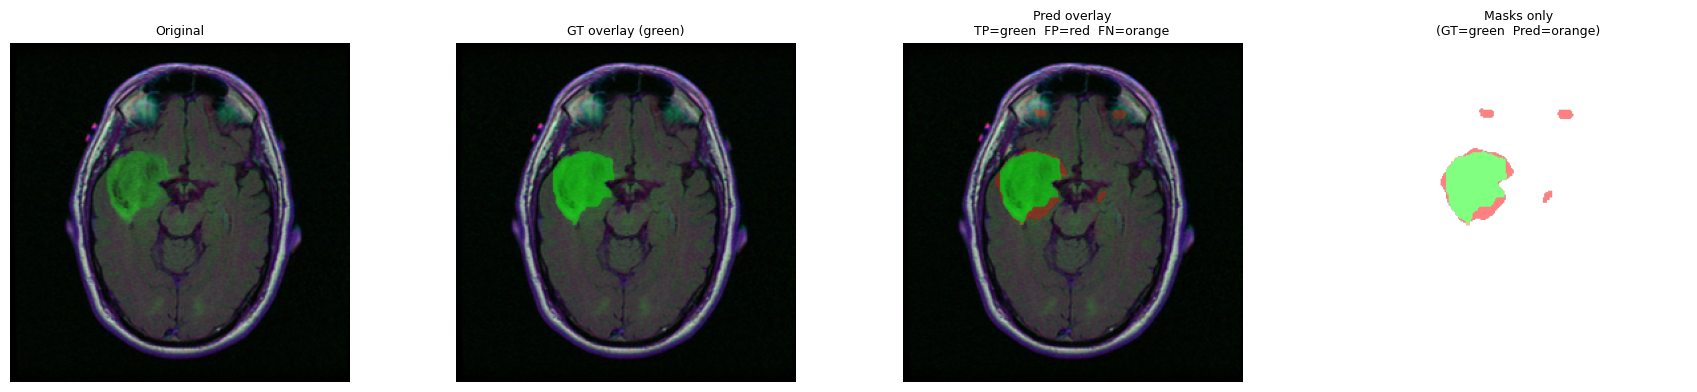

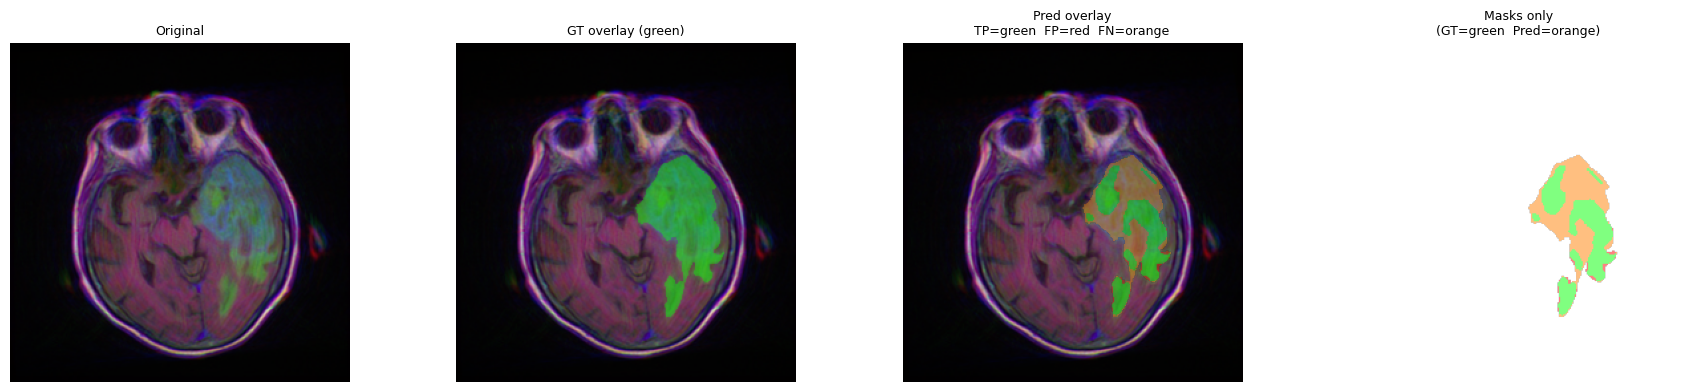

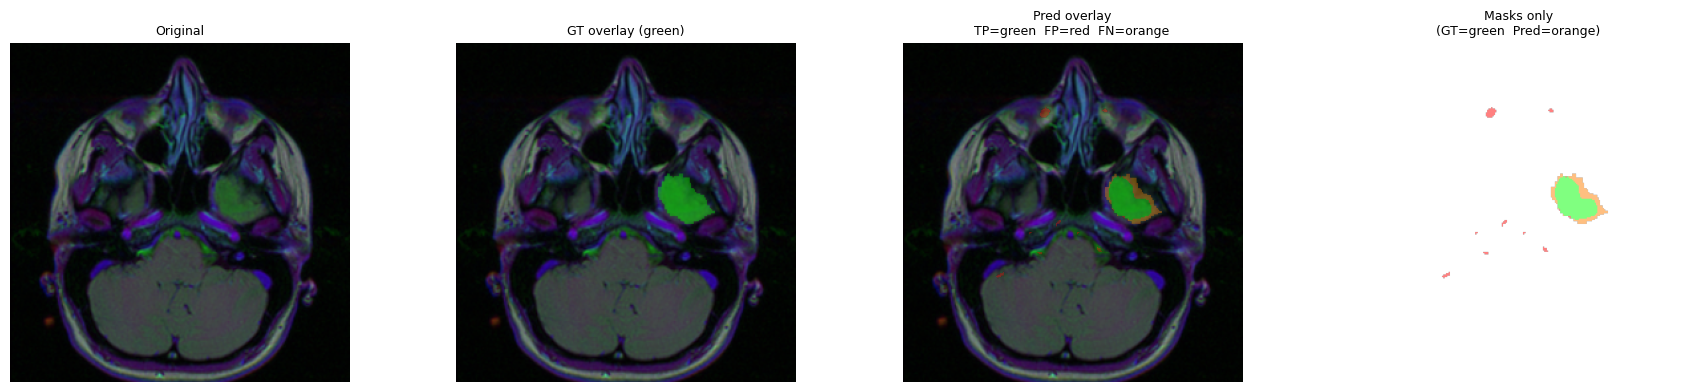

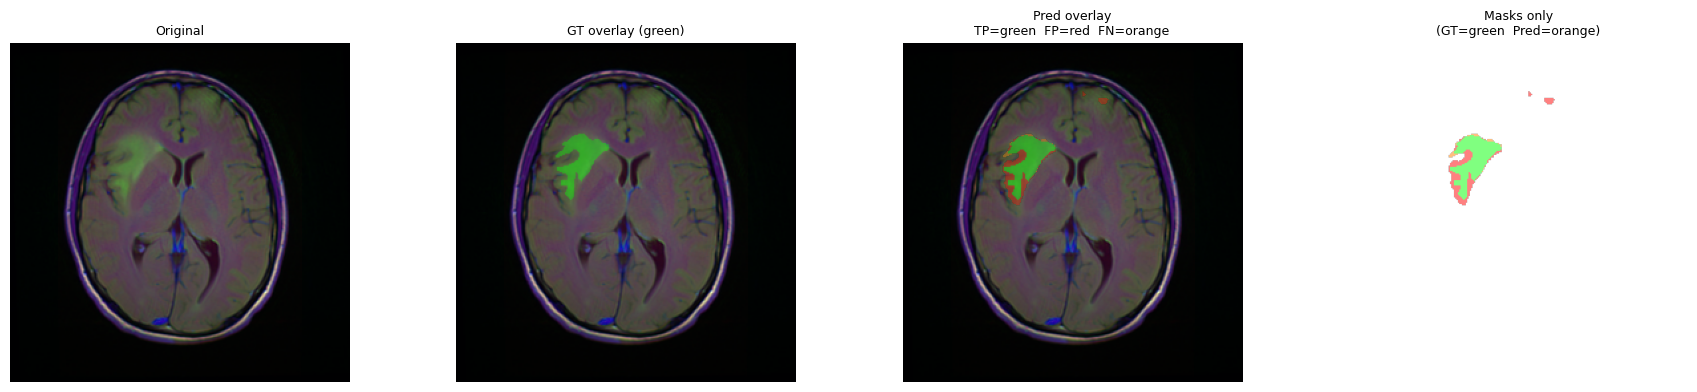

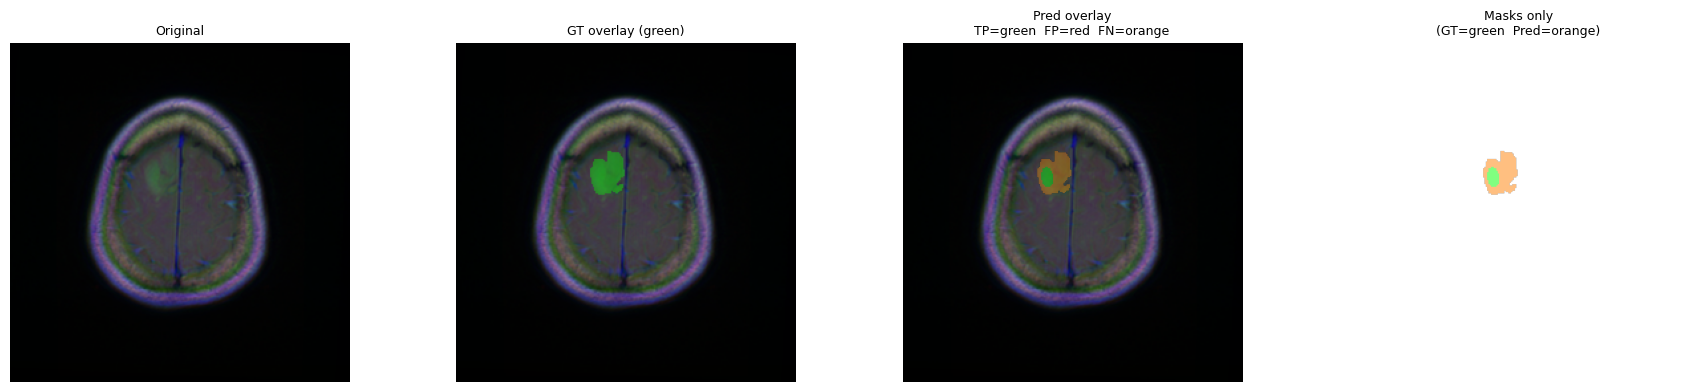

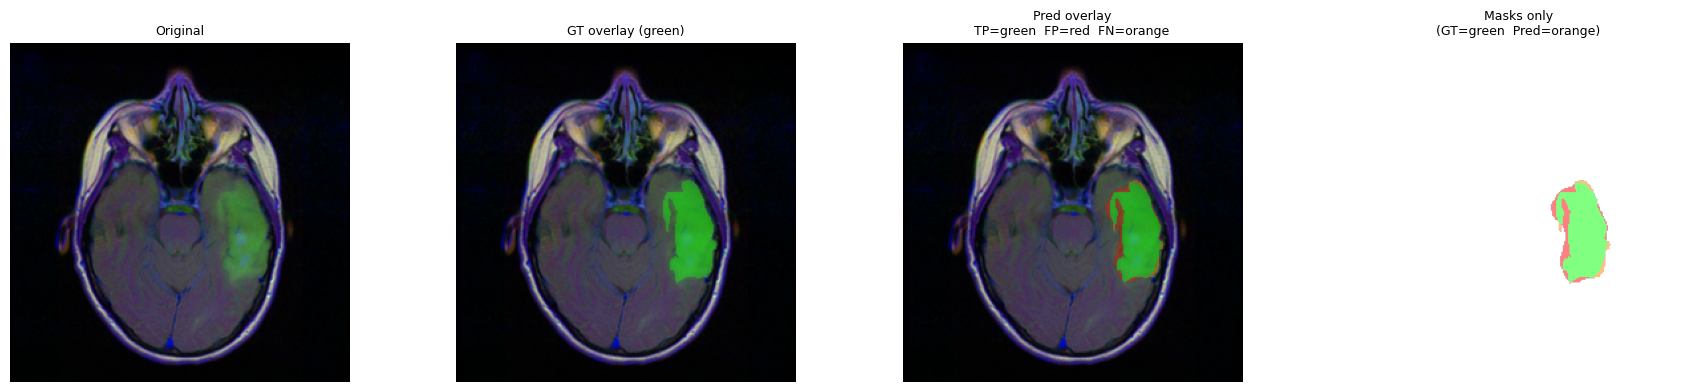

In [ ]:
from train_generalized import train, dice_loss, bce_loss, bce_dice_loss, focal_loss, tversky_loss
from eval import evaluate, evaluate_losses, evaluate_classification

trained_model, results_bce = train(
    model,
    train_loader,
    val_loader,
    device,
    loss_fn=bce_loss,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": 5, "gamma": 0.1},
)

evaluate(results_bce)

Epoch 1/10: 100%|██████████| 137/137 [00:03<00:00, 37.97it/s, train_loss=0.5673]


Epoch 1/10 - Avg Train Loss: 0.5673


Epoch 2/10: 100%|██████████| 137/137 [00:03<00:00, 38.87it/s, train_loss=0.4154]


Epoch 2/10 - Avg Train Loss: 0.4154


Epoch 3/10: 100%|██████████| 137/137 [00:03<00:00, 41.91it/s, train_loss=0.3963]


...

Epoch 8/10 - Avg Train Loss: 0.3732


Epoch 9/10: 100%|██████████| 137/137 [00:03<00:00, 42.67it/s, train_loss=0.3656]


Epoch 9/10 - Avg Train Loss: 0.3656


Epoch 10/10: 100%|██████████| 137/137 [00:03<00:00, 42.68it/s, train_loss=0.3712]


Epoch 10/10 - Avg Train Loss: 0.3712
Final Val Dice: 0.5221
Final Val IoU : 0.4230


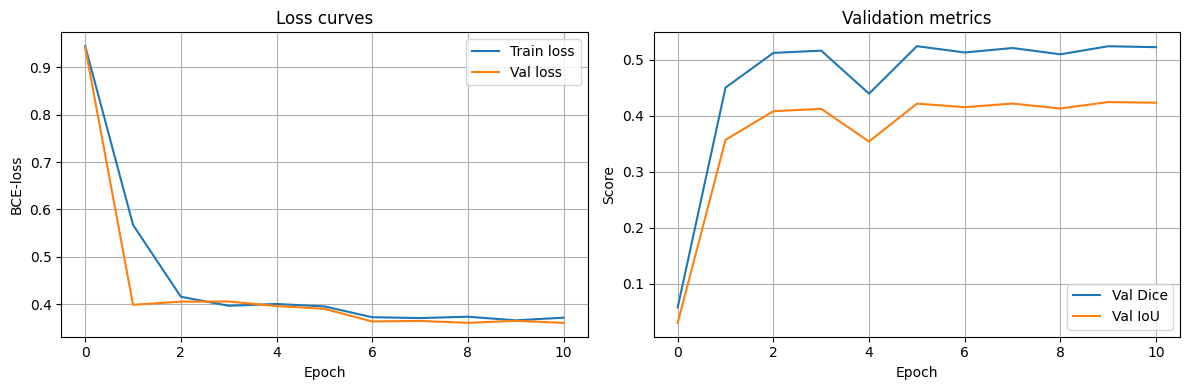

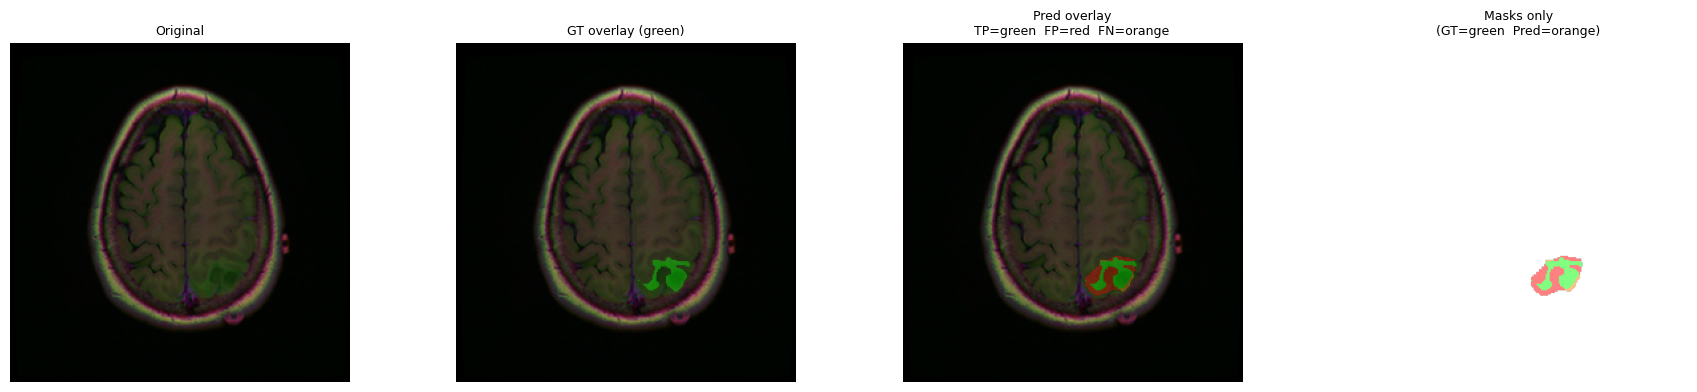

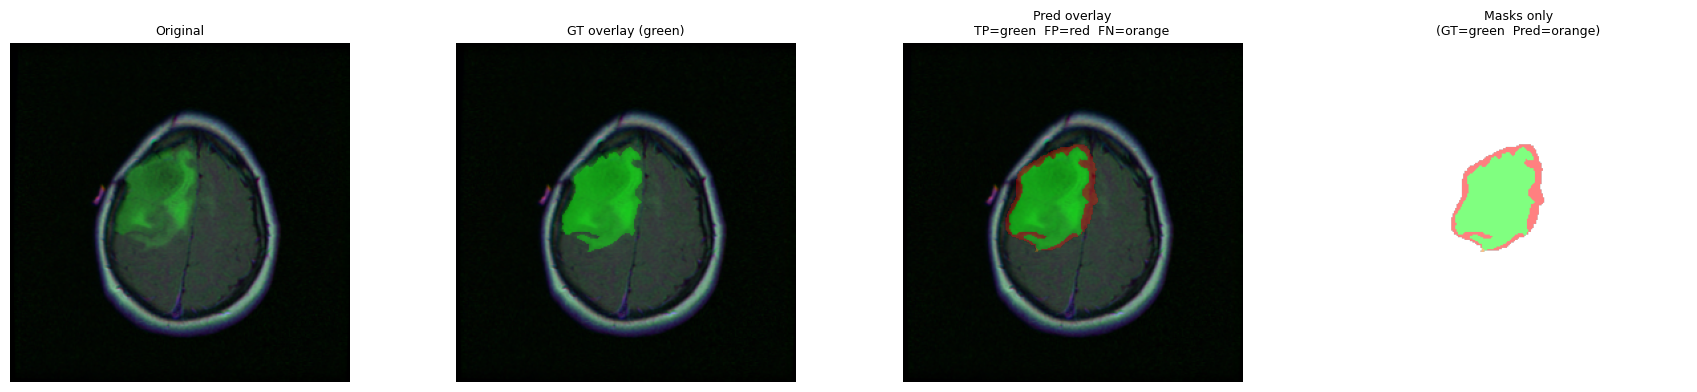

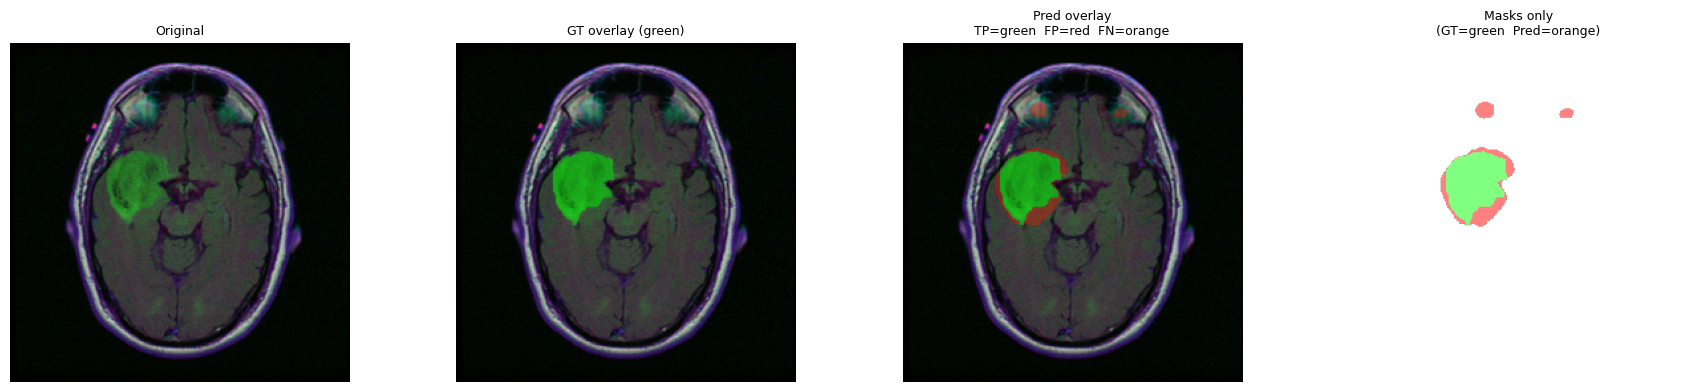

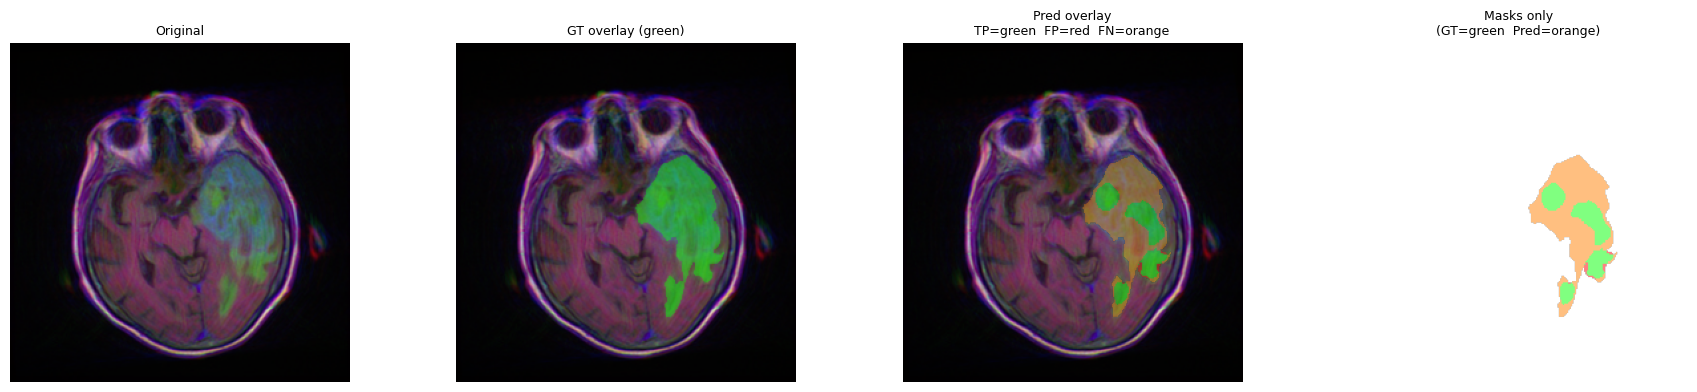

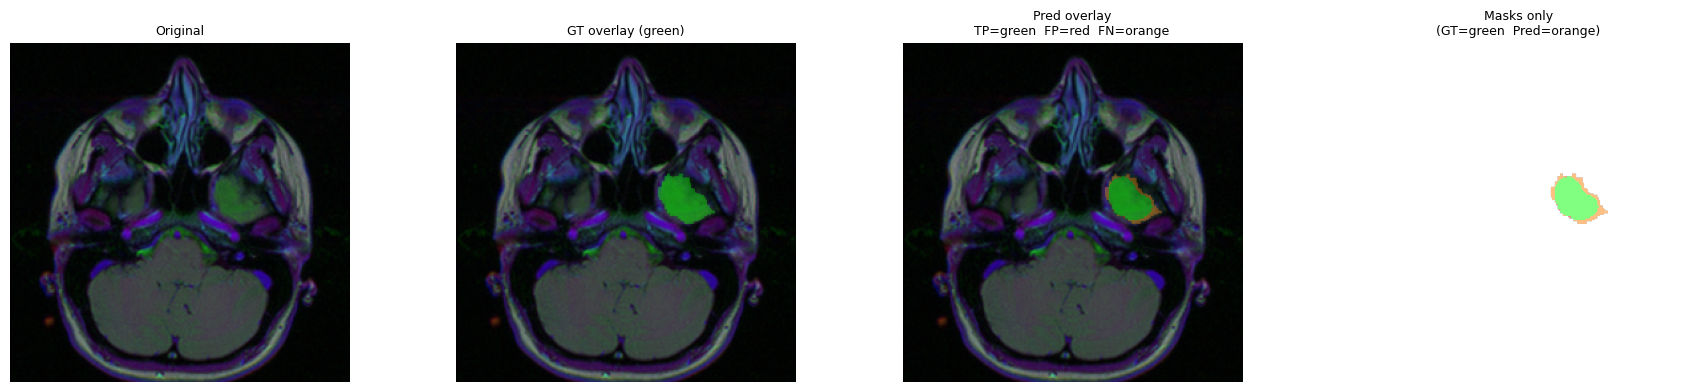

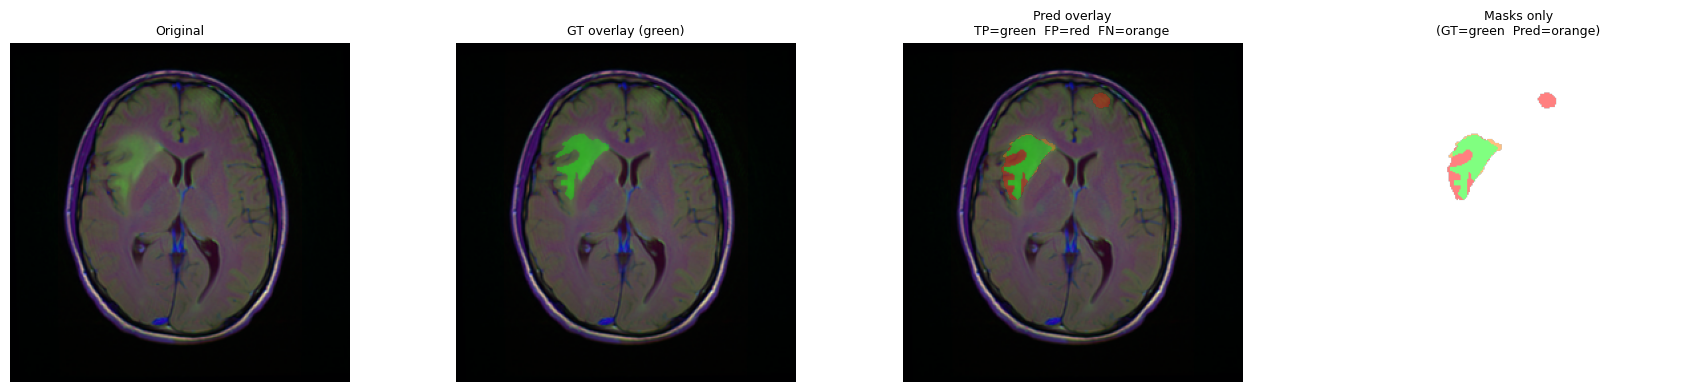

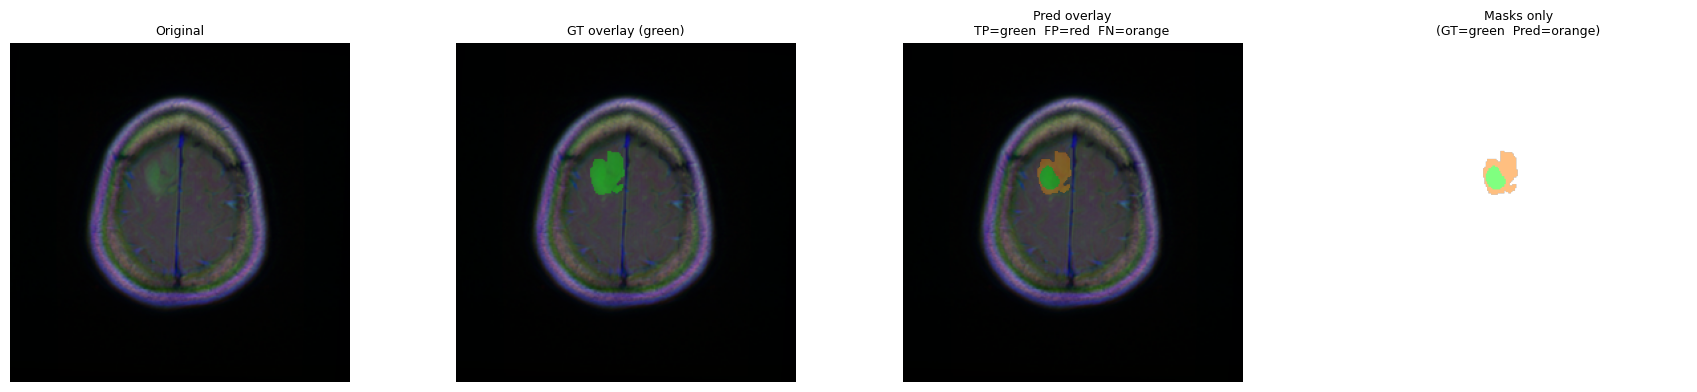

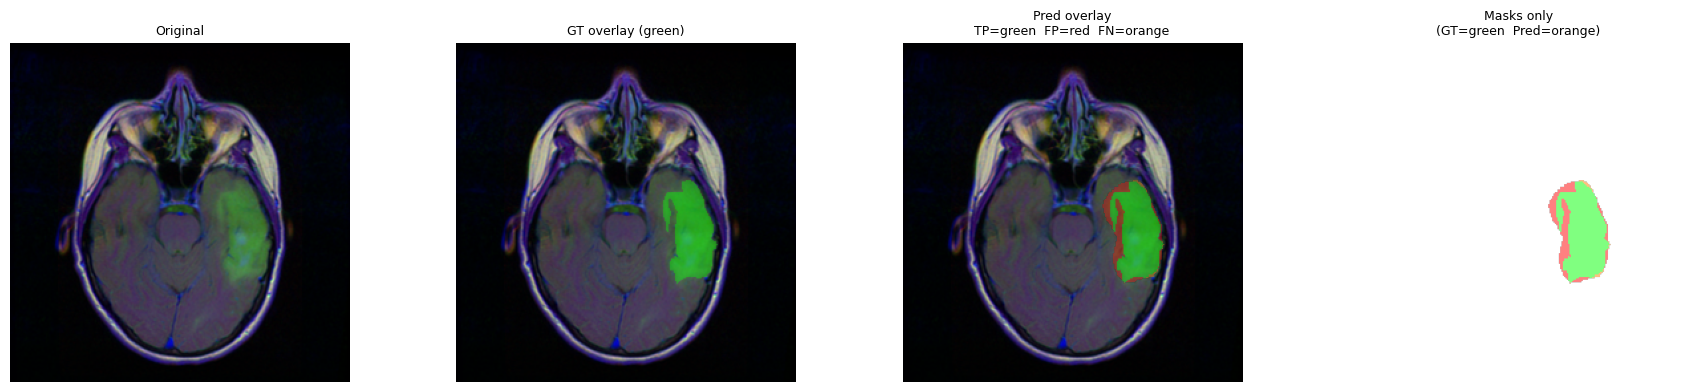

In [7]:
model = BaselineUNet()
device = torch.device('cuda')

trained_model, results_dice = train(
    model,
    train_loader,
    val_loader,
    device,
    loss_fn=dice_loss,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": 5, "gamma": 0.1},
)

evaluate(results_dice)

Epoch 1/10: 100%|██████████| 137/137 [00:03<00:00, 37.76it/s, train_loss=0.6533]


Epoch 1/10 - Avg Train Loss: 0.6533


Epoch 2/10: 100%|██████████| 137/137 [00:03<00:00, 37.90it/s, train_loss=0.3650]


Epoch 2/10 - Avg Train Loss: 0.3650


Epoch 3/10: 100%|██████████| 137/137 [00:03<00:00, 40.84it/s, train_loss=0.3698]


...

Epoch 8/10 - Avg Train Loss: 0.3134


Epoch 9/10: 100%|██████████| 137/137 [00:03<00:00, 40.92it/s, train_loss=0.3135]


Epoch 9/10 - Avg Train Loss: 0.3135


Epoch 10/10: 100%|██████████| 137/137 [00:03<00:00, 41.05it/s, train_loss=0.3112]


Epoch 10/10 - Avg Train Loss: 0.3112
Final Val Dice: 0.5503
Final Val IoU : 0.4490


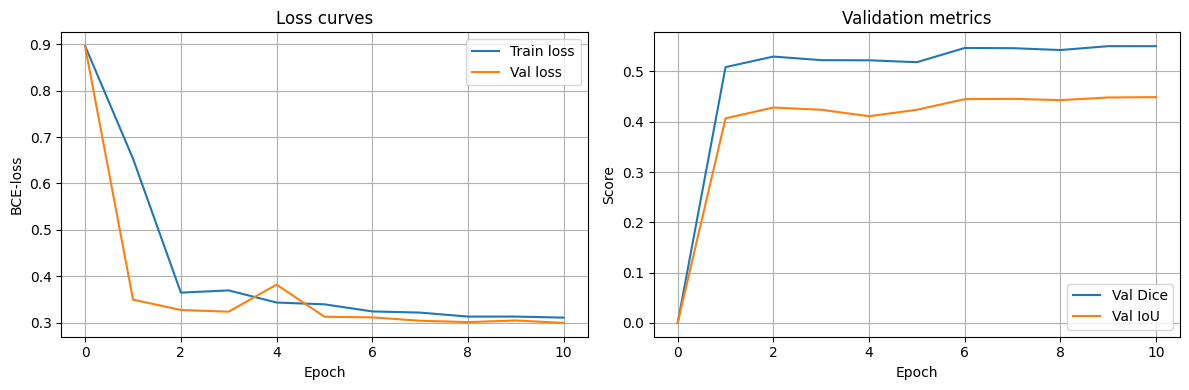

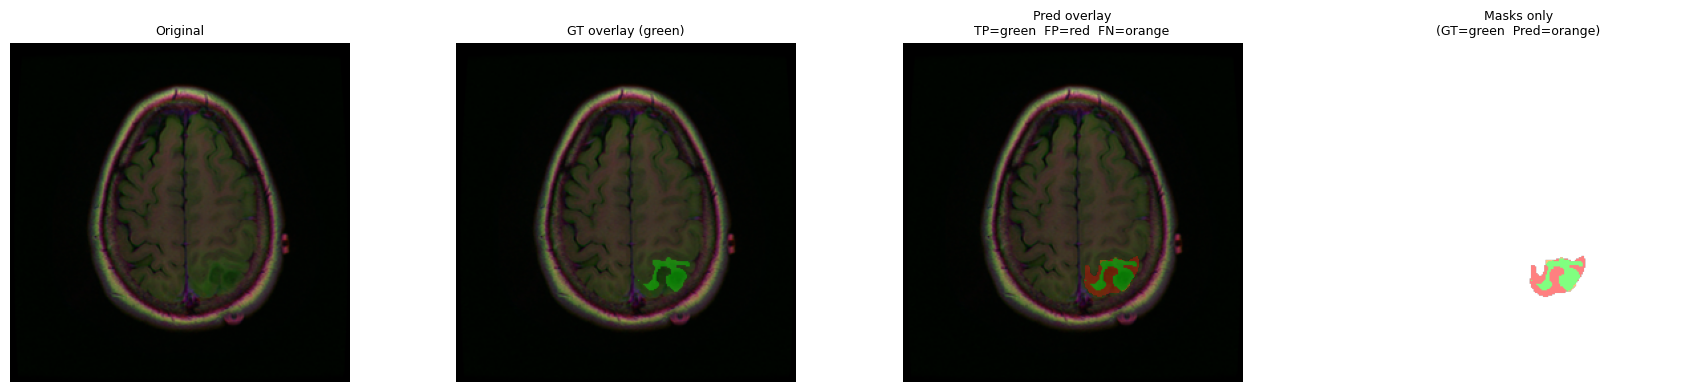

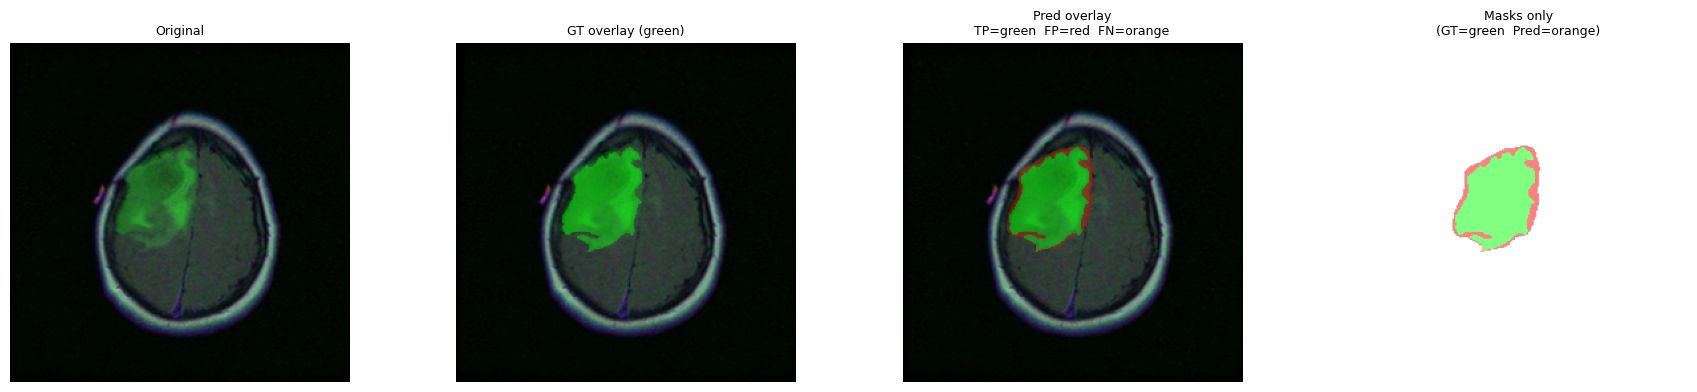

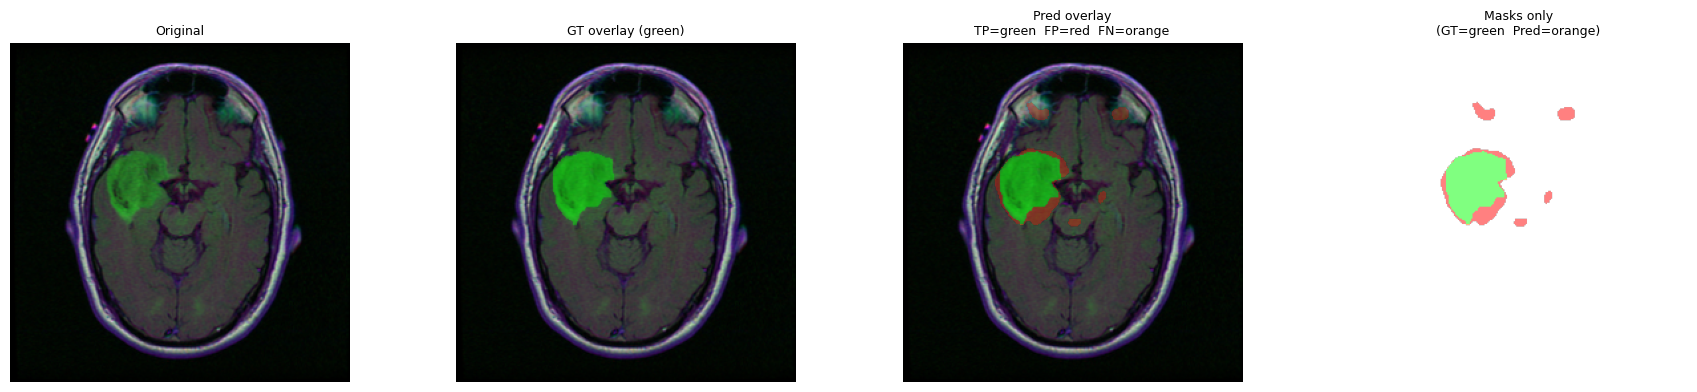

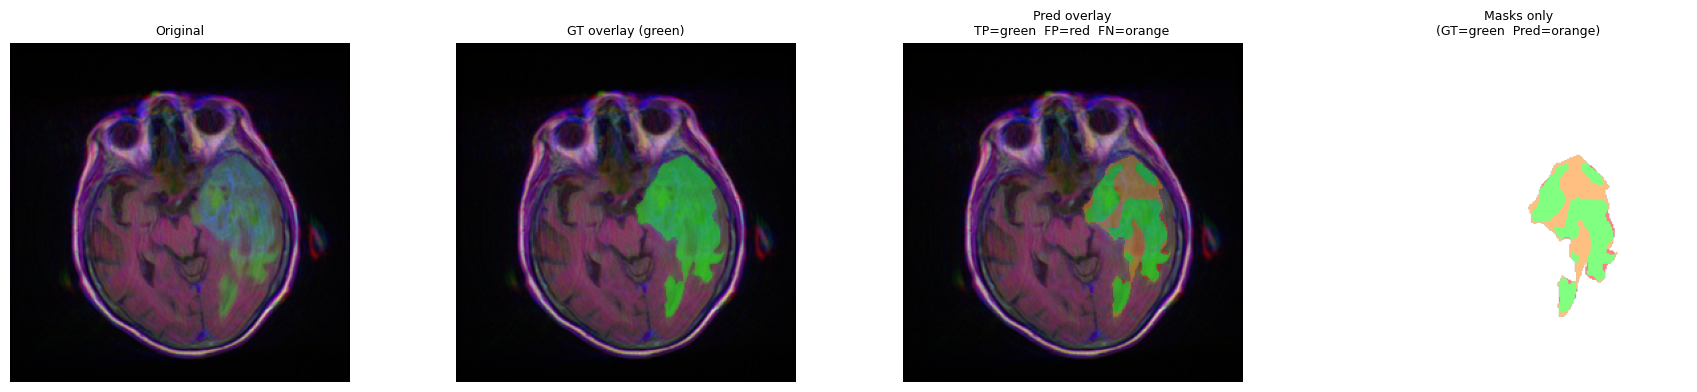

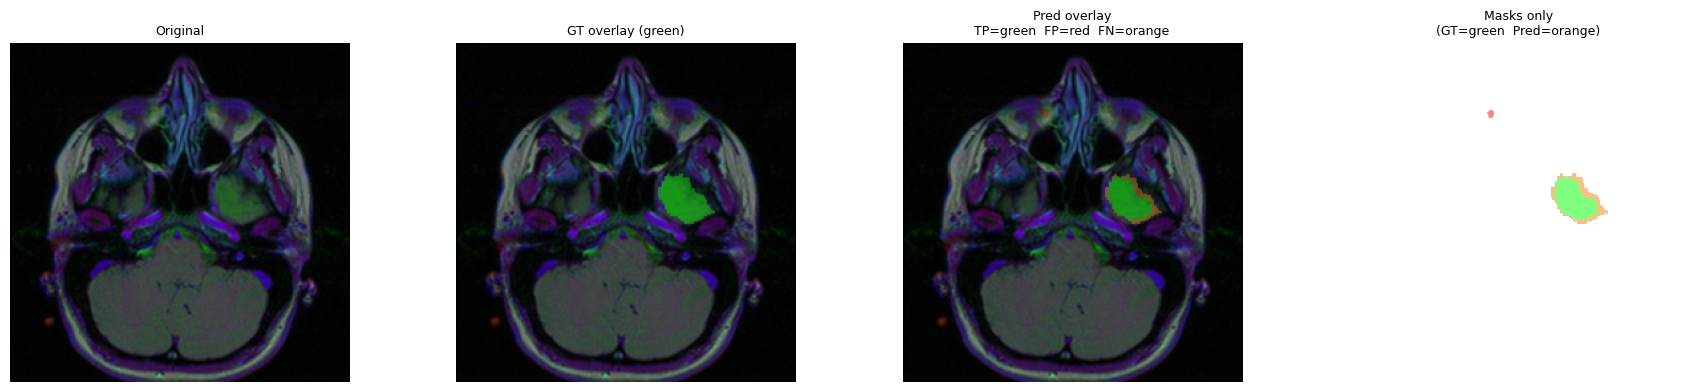

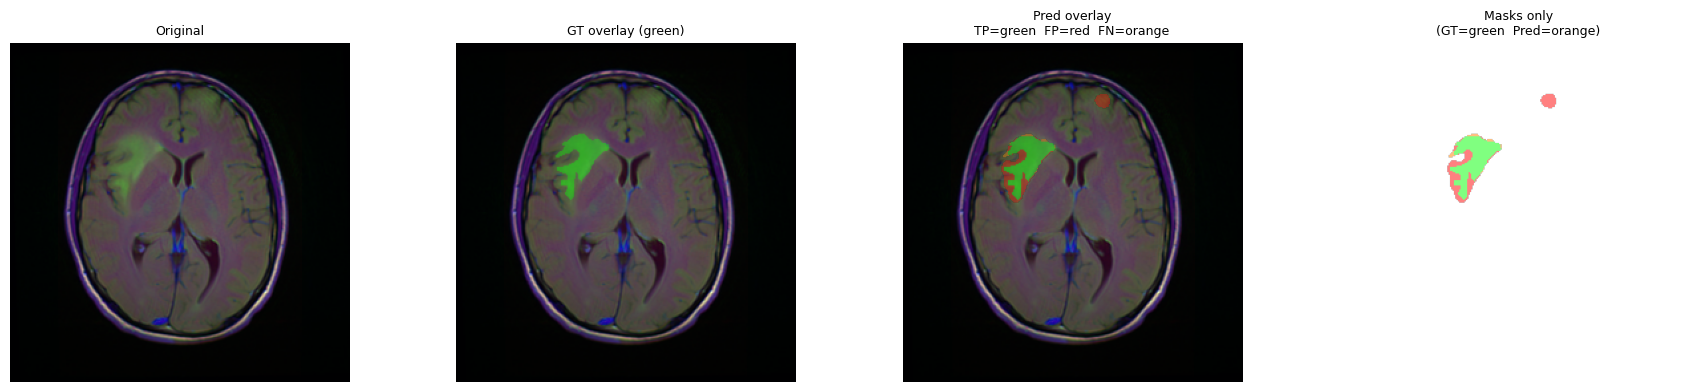

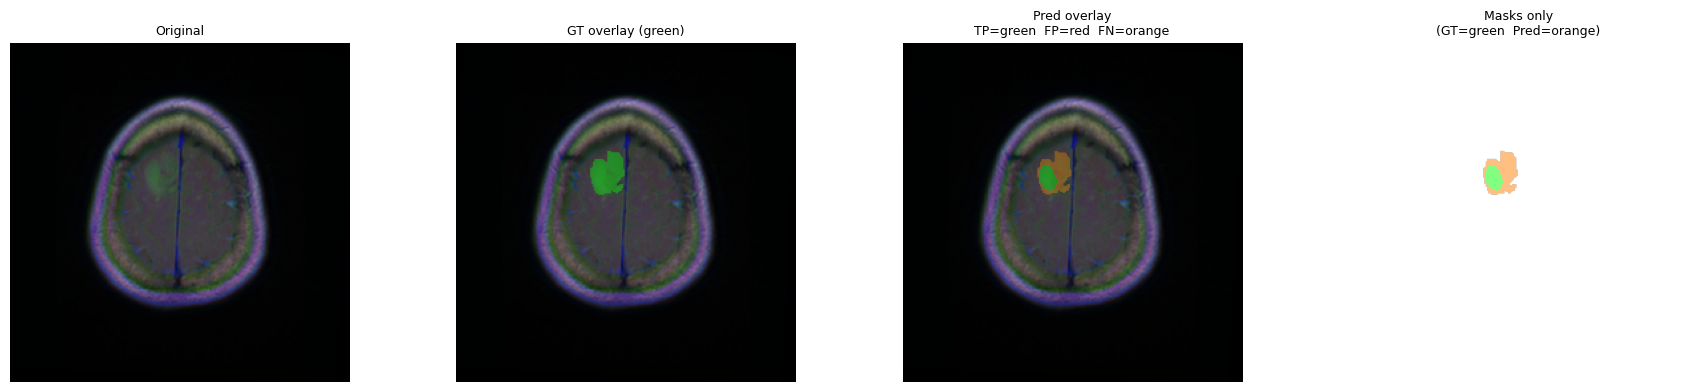

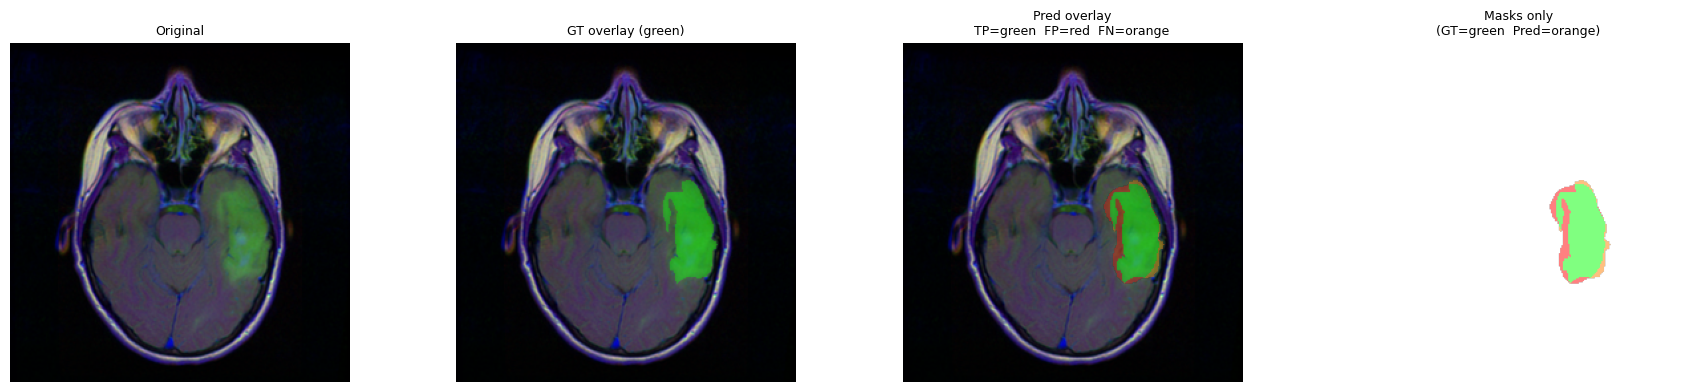

In [8]:
model = BaselineUNet()
device = torch.device('cuda')
trained_model, results_bce_dice = train(
    model,
    train_loader,
    val_loader,
    device,
    loss_fn=bce_dice_loss,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": 5, "gamma": 0.1},
)

evaluate(results_bce_dice)

Epoch 1/10: 100%|██████████| 137/137 [00:03<00:00, 38.85it/s, train_loss=0.0161]


Epoch 1/10 - Avg Train Loss: 0.0161


Epoch 2/10: 100%|██████████| 137/137 [00:03<00:00, 37.32it/s, train_loss=0.0005]


Epoch 2/10 - Avg Train Loss: 0.0005


Epoch 3/10: 100%|██████████| 137/137 [00:03<00:00, 42.96it/s, train_loss=0.0004]


...

Epoch 8/10 - Avg Train Loss: 0.0002


Epoch 9/10: 100%|██████████| 137/137 [00:03<00:00, 44.36it/s, train_loss=0.0002]


Epoch 9/10 - Avg Train Loss: 0.0002


Epoch 10/10: 100%|██████████| 137/137 [00:03<00:00, 43.48it/s, train_loss=0.0002]


Epoch 10/10 - Avg Train Loss: 0.0002
Final Val Dice: 0.3811
Final Val IoU : 0.3006


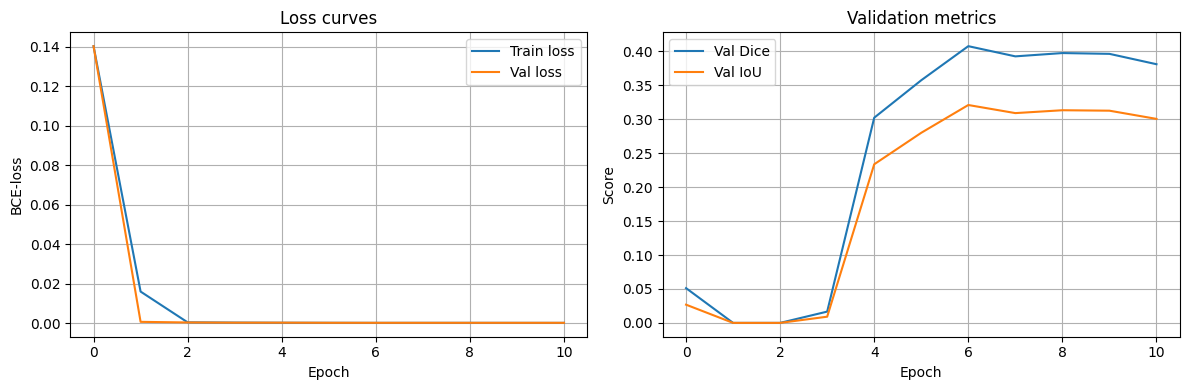

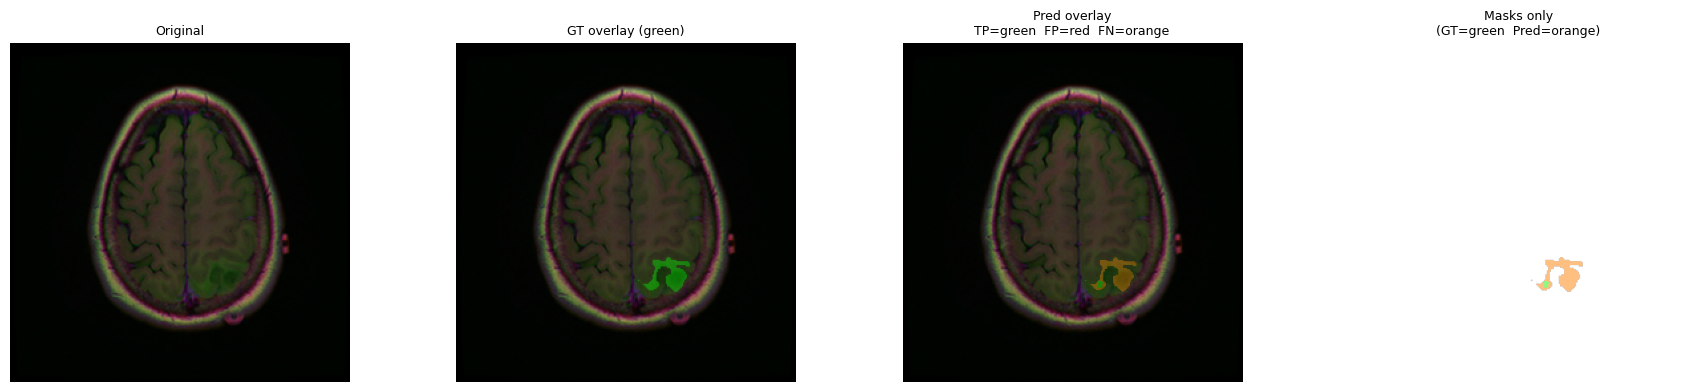

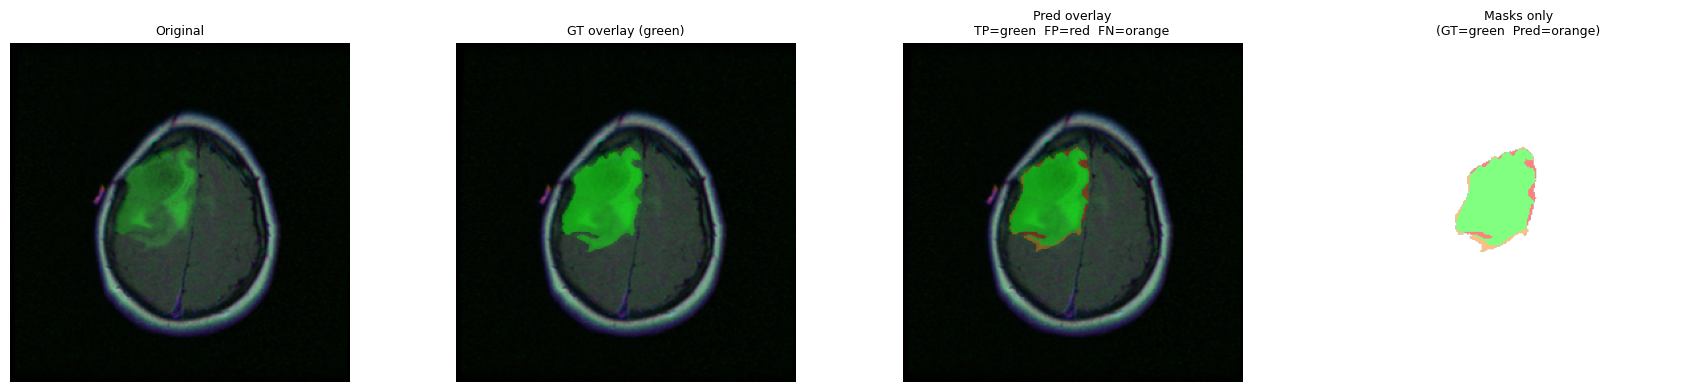

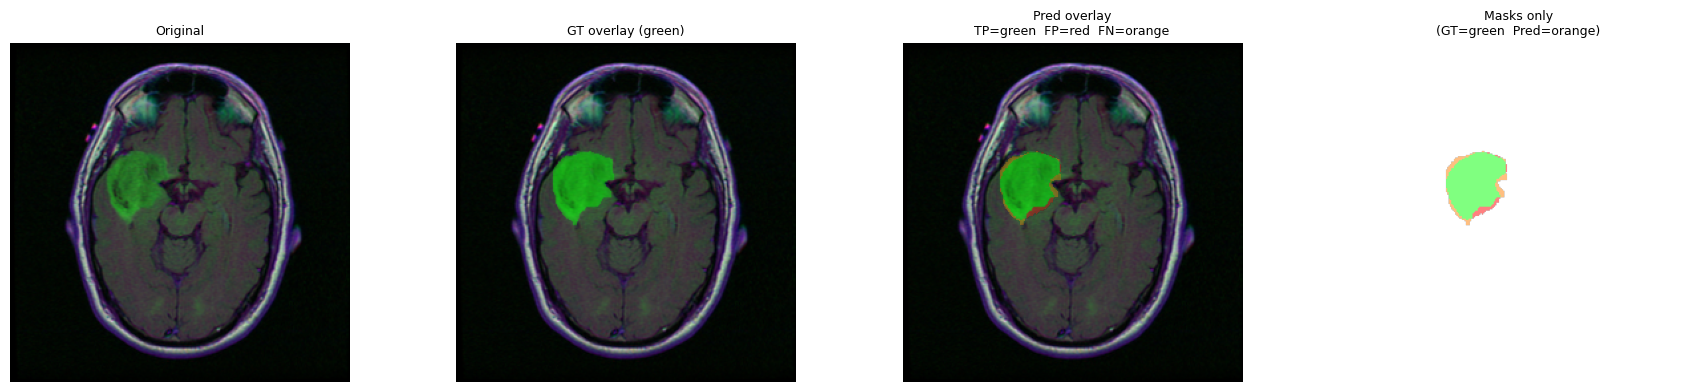

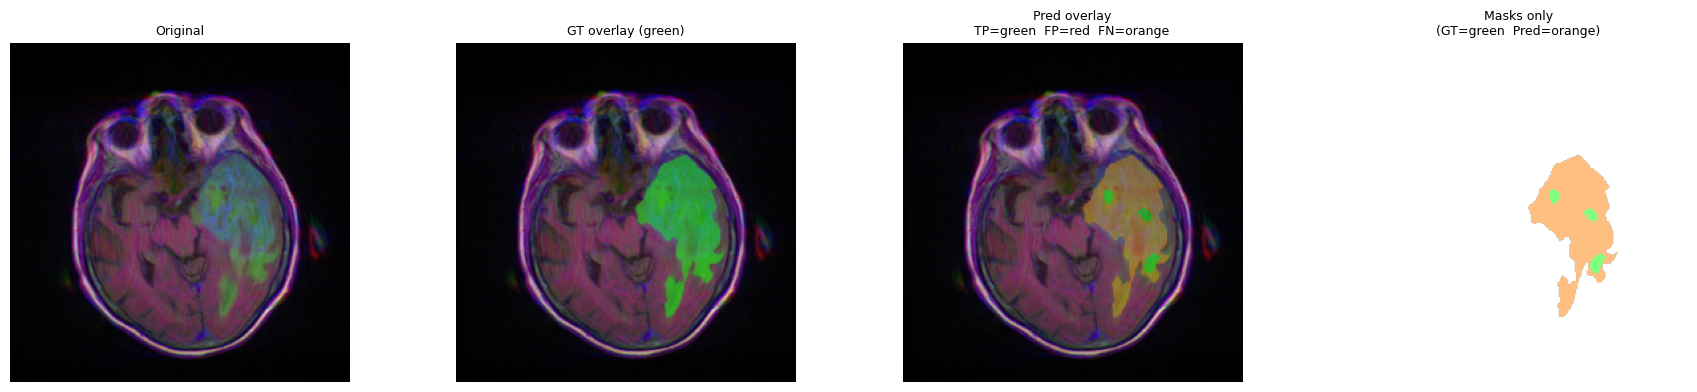

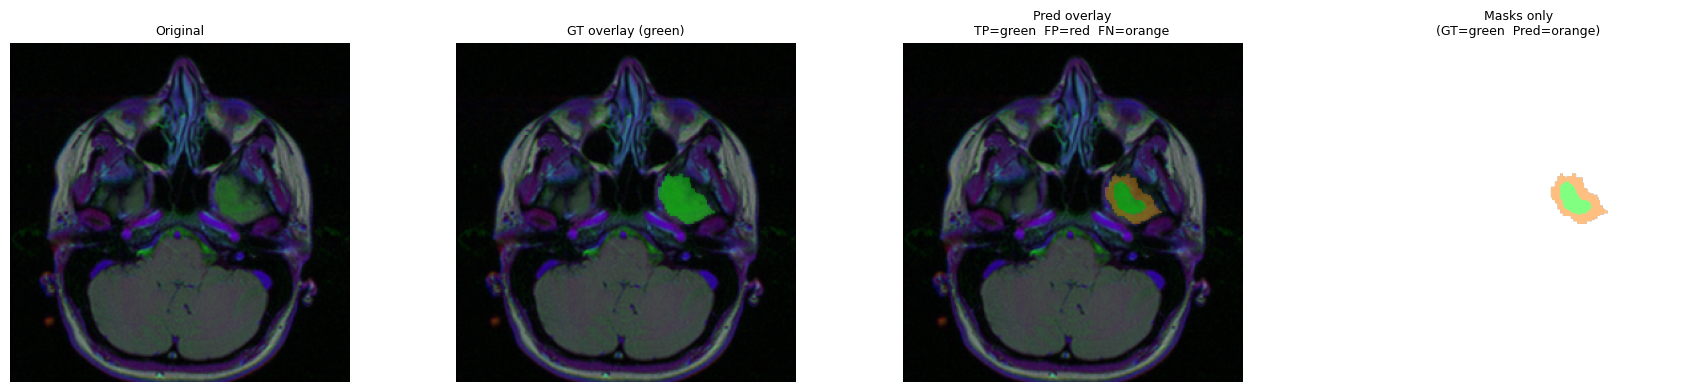

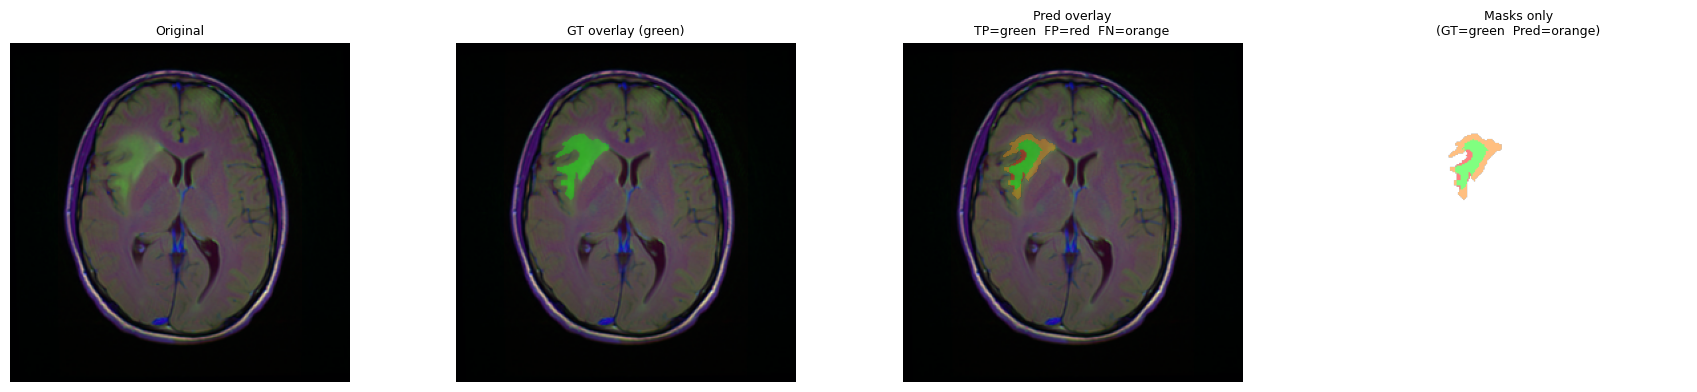

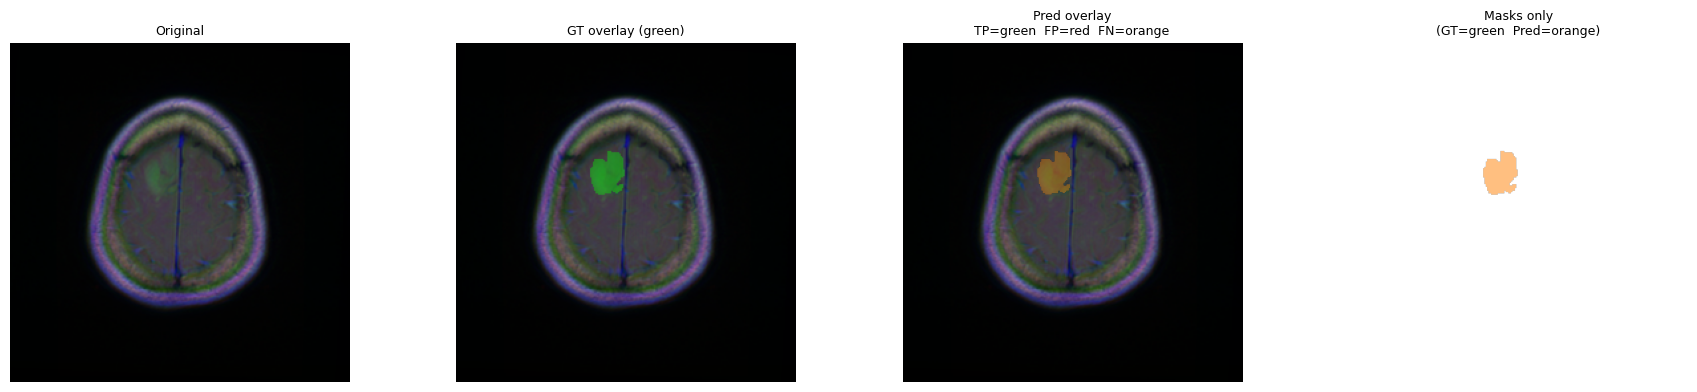

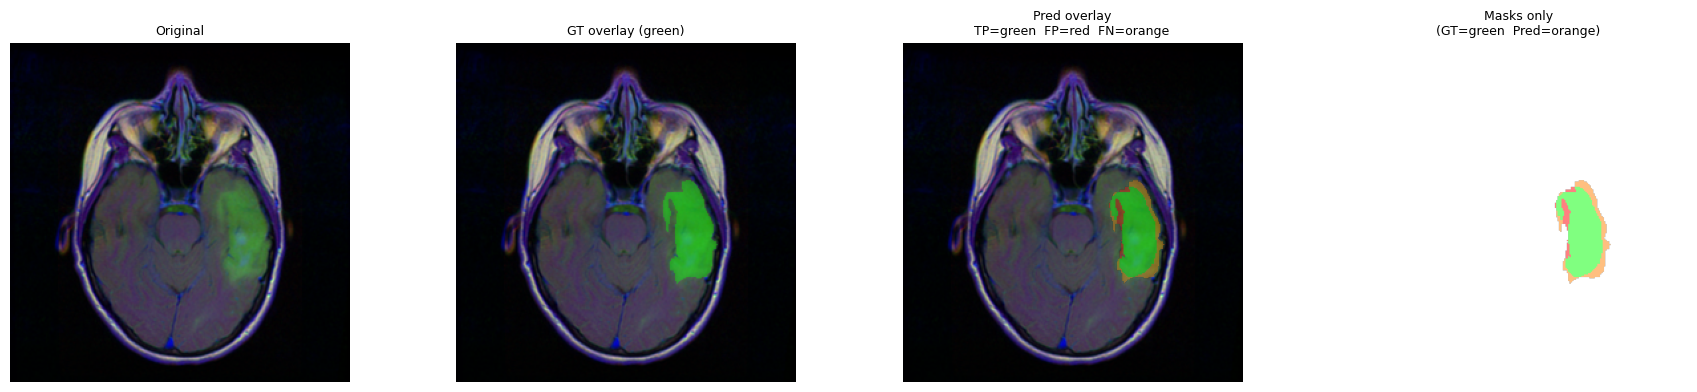

In [9]:
model = BaselineUNet()
device = torch.device('cuda')

trained_model, results_focal = train(
    model,
    train_loader,
    val_loader,
    device,
    loss_fn=focal_loss,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": 5, "gamma": 0.1},
)

evaluate(results_focal)

Epoch 1/10: 100%|██████████| 137/137 [00:03<00:00, 41.29it/s, train_loss=0.6488]


Epoch 1/10 - Avg Train Loss: 0.6488


Epoch 2/10: 100%|██████████| 137/137 [00:03<00:00, 42.48it/s, train_loss=0.4204]


Epoch 2/10 - Avg Train Loss: 0.4204


Epoch 3/10: 100%|██████████| 137/137 [00:03<00:00, 43.49it/s, train_loss=0.4011]


...

Epoch 8/10 - Avg Train Loss: 0.3617


Epoch 9/10: 100%|██████████| 137/137 [00:03<00:00, 43.58it/s, train_loss=0.3726]


Epoch 9/10 - Avg Train Loss: 0.3726


Epoch 10/10: 100%|██████████| 137/137 [00:03<00:00, 43.20it/s, train_loss=0.3614]


Epoch 10/10 - Avg Train Loss: 0.3614
Final Val Dice: 0.5210
Final Val IoU : 0.4221


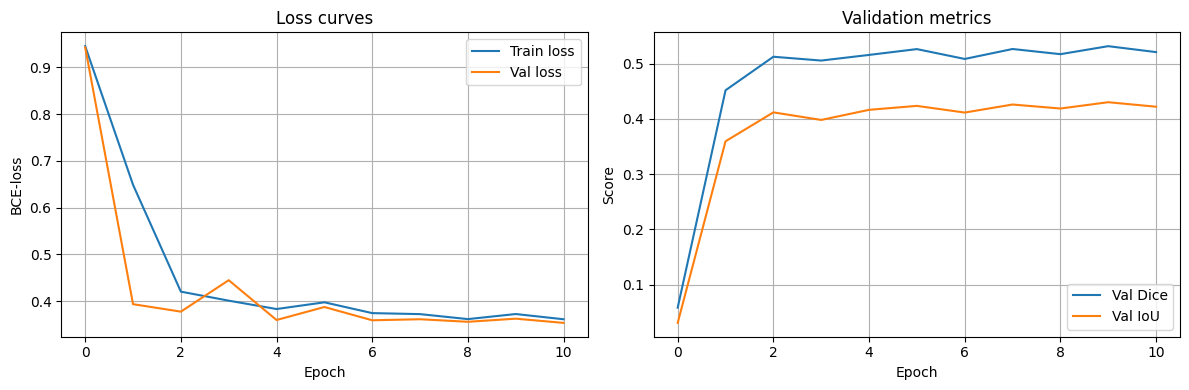

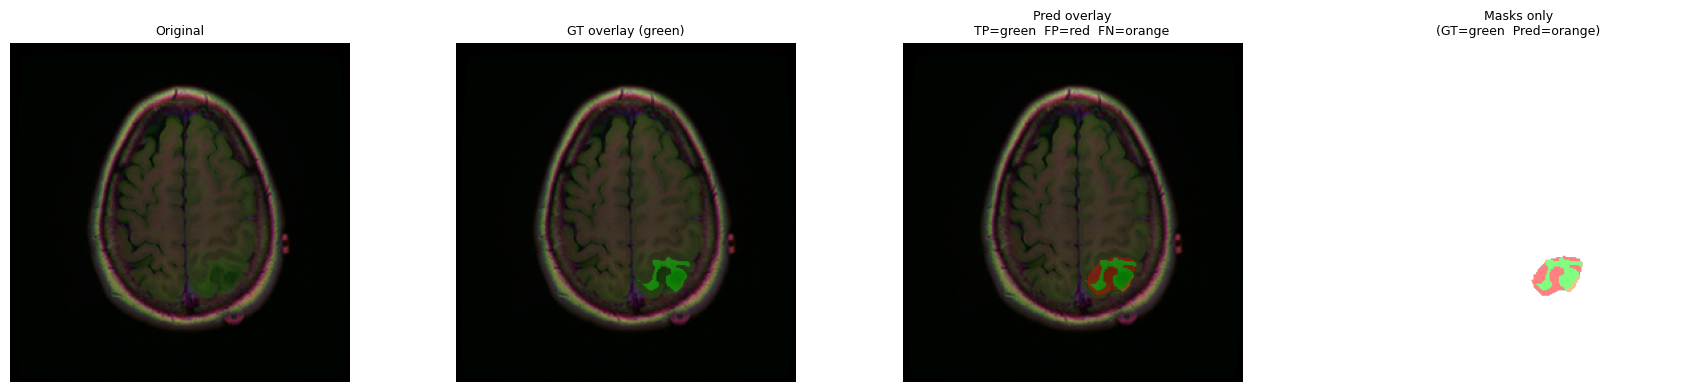

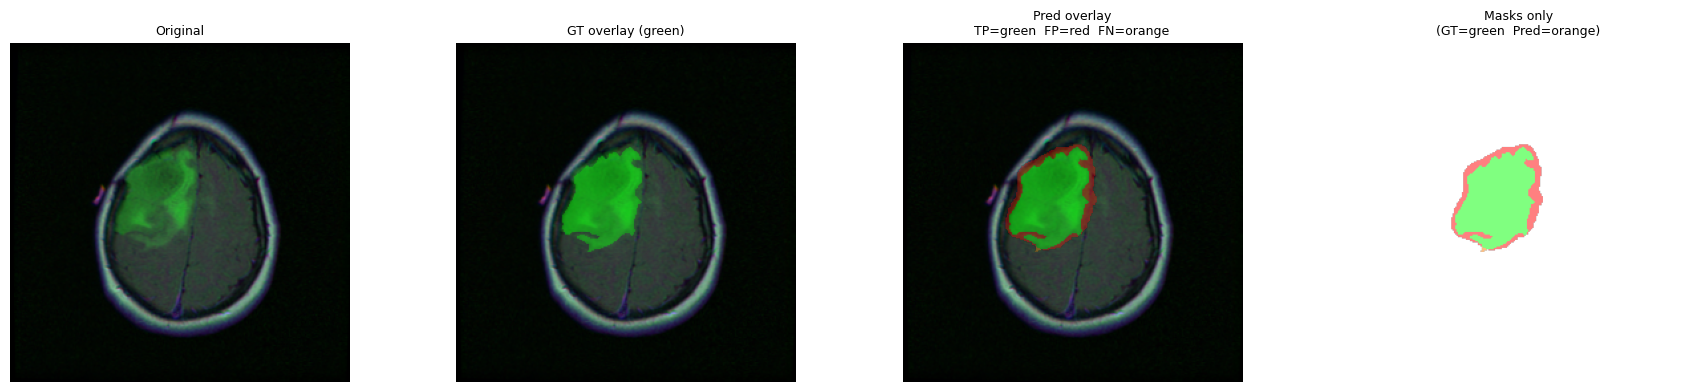

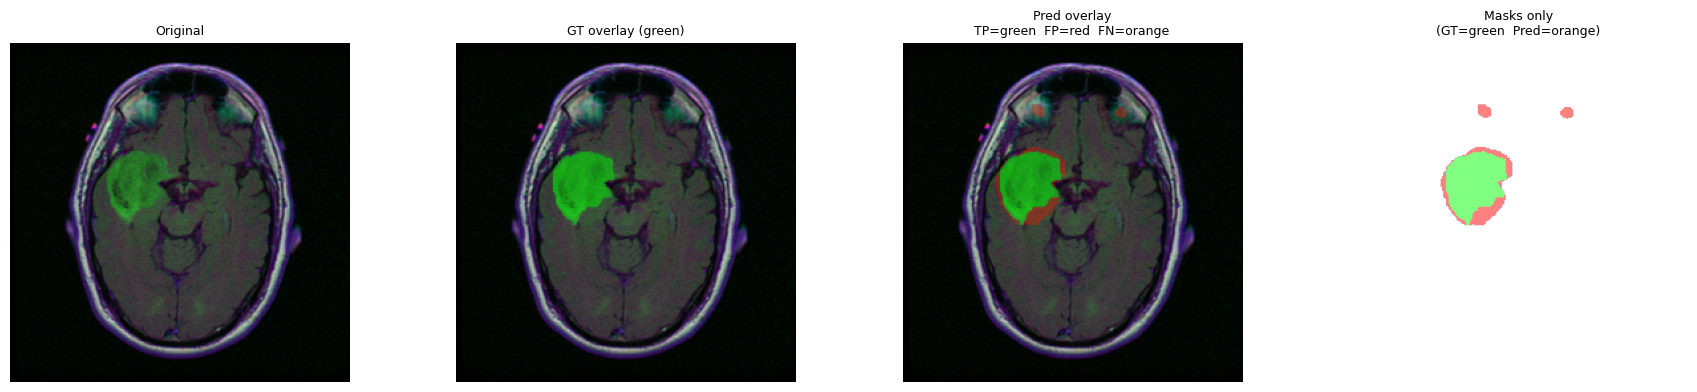

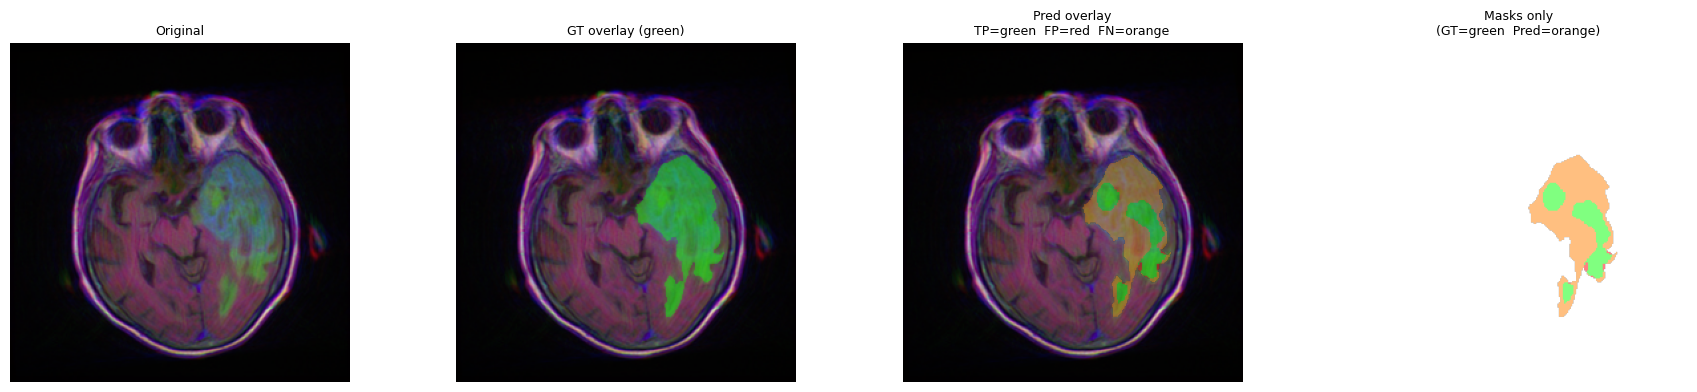

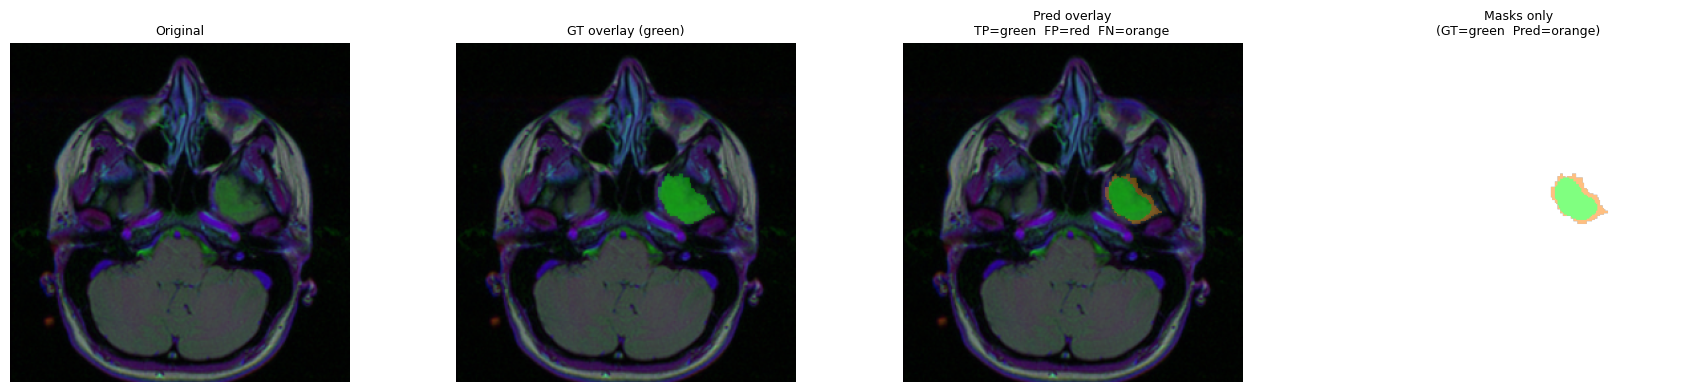

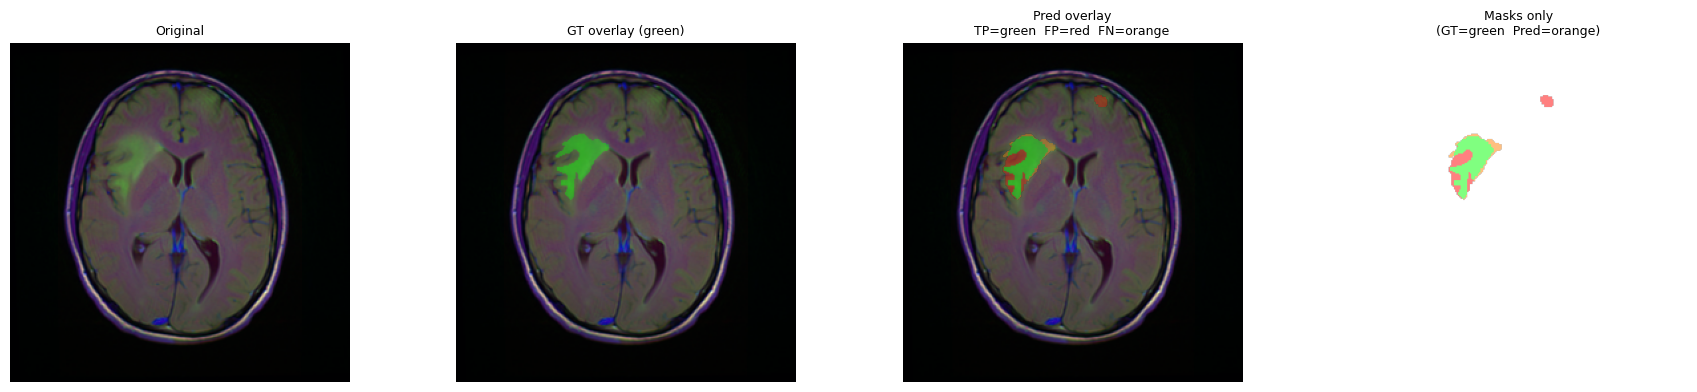

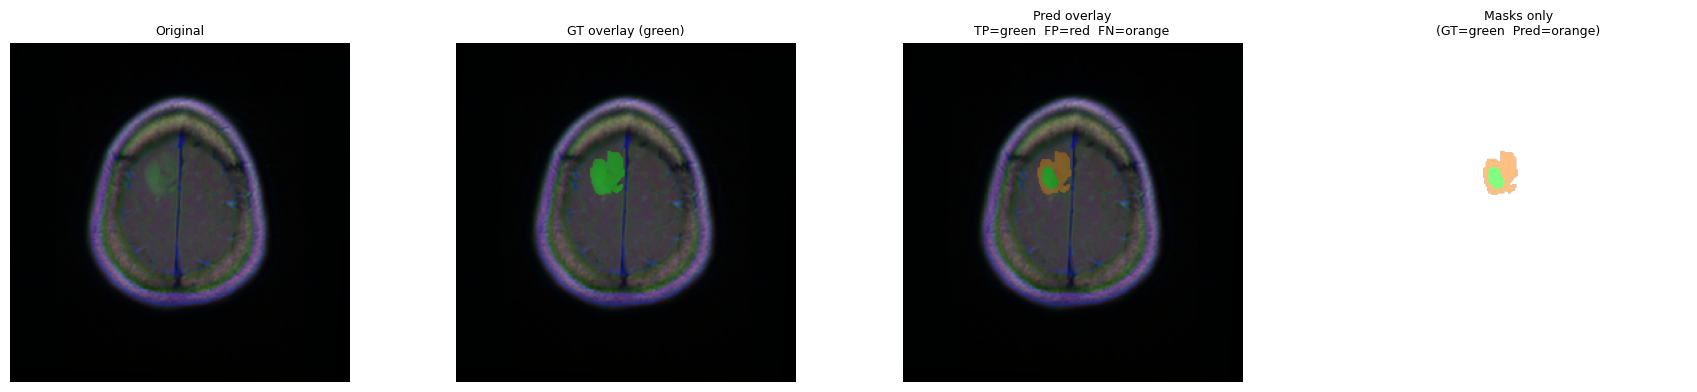

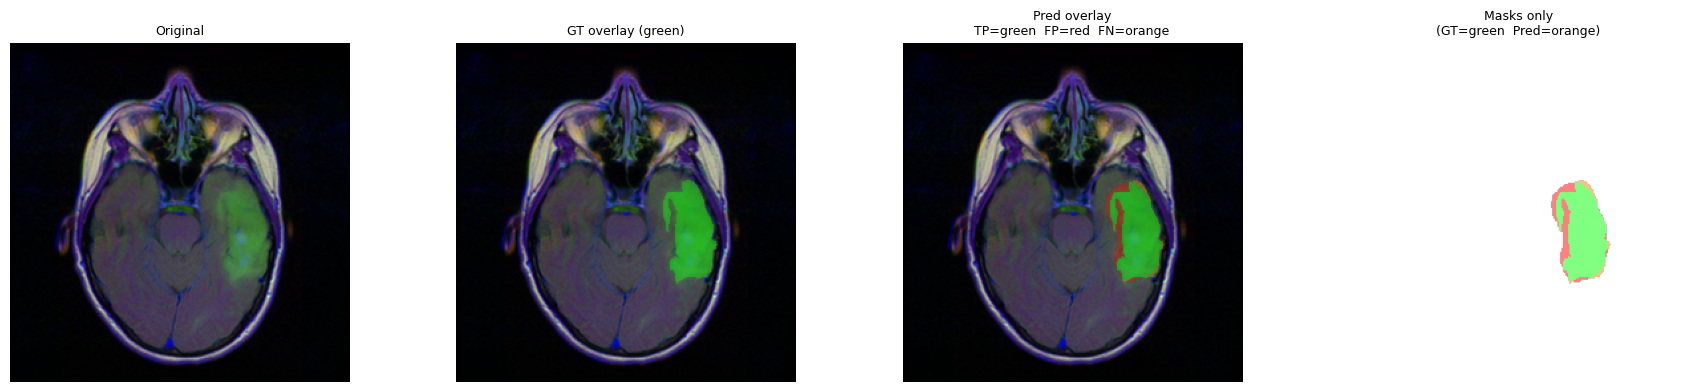

In [10]:
model = BaselineUNet()
device = torch.device('cuda')

trained_model, results_tversky = train(
    model,
    train_loader,
    val_loader,
    device,
    loss_fn=tversky_loss,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": 5, "gamma": 0.1},
)

evaluate(results_tversky)

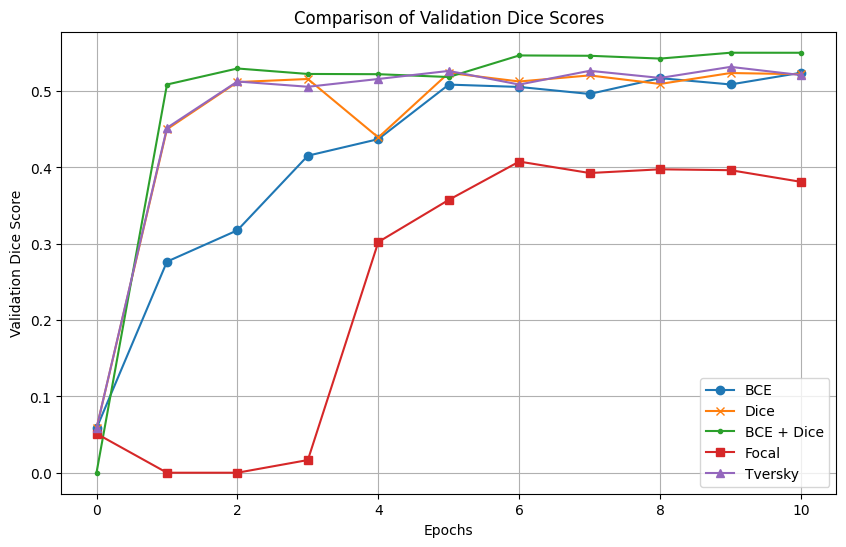

In [11]:
results_list = [
    results_bce,
    results_dice,
    results_bce_dice,
    results_focal,
    results_tversky
]
labels_list = [
    "BCE",
    "Dice",
    "BCE + Dice",
    "Focal",
    "Tversky"
]
evaluate_losses(results_list, labels_list)